# A dietary risk assessment of Aflatoxin 

This notebook analyzes the diet survey responses, converts food-consumption categories into estimated *daily* intakes, and then derives exposure metrics such as:

- **EDI (Estimated Daily Intake)** for wheat, rice, and milk
- **MOE (Margin of Exposure)** and a combined (total) MOE
- A simple **cancer-risk proxy** based on an average potency factor

It then explores relationships and differences across demographics using group summaries, correlation plots, and hypothesis tests.


### Step 01 — Mount Google Drive

- Imports Colab's `drive` helper.
- Mounts your Google Drive at `/content/drive` so the notebook can read/write files stored there.

In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 02 — Import required libraries

- Loads the Python packages used for data manipulation and visualization (e.g., pandas/numpy/matplotlib/seaborn).
- Keeping imports near the top makes dependencies clear and avoids repeated imports later.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 03 — Load survey responses (Excel)

- Reads the survey response spreadsheet into a pandas DataFrame named `smm`.
- After loading, `smm` is the main table used throughout the analysis.

In [ ]:
smm = pd.read_excel('/content/drive/My Drive/MS Data Science/Semester 1/Statistical and Mathematical Models for DS/Research Project/SMM - Survey Responses.xlsx')

### Step 04 — Preview the dataset

- Displays the `smm` DataFrame so you can visually verify the loaded/engineered columns.
- Helpful for spot-checking whether transformations worked as expected.

In [ ]:
smm

,Gender,Age,Location,Height Range,Weight Range,Weight,Wheat Consumption,Wheat Intake,Daily Wheat Intake,Rice Consumption,Rice Intake,Daily Rice Intake,Consumed Milk Type,Milk Consumption,Milk Intake,Daily Milk Intake,Have you heard of aflatoxins?
0,Male,25-34,Urban,5 feet 6 inches - 6 feet,61 kg - 70 kg,65.0,Daily,(2 roti) 100g,NaN,Weekly,(2 plate) 300g,NaN,Fresh Milk,Daily,(3 cups) 750ml,NaN,No
1,Female,25-34,Urban,5 feet - 5 feet 6 inches,40 kg - 50 kg,48.0,Daily,(3 roti) 150g,NaN,Several times a week,(2 plate) 300g,NaN,Fresh Milk,Daily,(3 cups) 750ml,NaN,Yes
2,Male,35-44,Urban,5 feet 6 inches - 6 feet,81 kg - 90 kg,83.0,Daily,(3 roti) 150g,NaN,Weekly,(2 plate) 300g,NaN,Fresh Milk,Rarely,(1 cup) 250ml,NaN,Yes
3,Female,25-34,Urban,5 feet - 5 feet 6 inches,61 kg - 70 kg,65.0,Daily,(1 roti) 50 g,NaN,Weekly,(1 plate) 150g,NaN,Fresh Milk,Daily,(1 cup) 250ml,NaN,Yes
4,Female,18-24,Urban,5 feet - 5 feet 6 inches,61 kg - 70 kg,67.0,Daily,(2 roti) 100g,NaN,Weekly,(2 plate) 300g,NaN,Fresh Milk,Weekly,(1 cup) 250ml,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Female,18-24,Urban,5 feet - 5 feet 6 inches,81 kg - 90 kg,88.0,Daily,(1 roti) 50 g,NaN,Weekly,(1 plate) 150g,NaN,Fresh Milk,Daily,(1 cup) 250ml,NaN,Yes
188,Female,18-24,Suburban,5 feet - 5 feet 6 inches,61 kg - 70 kg,62.0,Daily,(1 roti) 50 g,NaN,Weekly,(1 plate) 150g,NaN,Packaged Milk,Several times a week,(1 cup) 250ml,NaN,Yes
189,Male,25-34,Urban,5 feet 6 inches - 6 feet,51 kg - 60 kg,56.0,Daily,(2 roti) 100g,NaN,Several times a week,(2 plate) 300g,NaN,Fresh Milk,Daily,(2 cups) 500ml,NaN,No
190,Female,18-24,Urban,5 feet - 5 feet 6 inches,71 kg - 80 kg,71.0,Daily,(1 roti) 50 g,NaN,Several times a week,(1 plate) 150g,NaN,Fresh Milk,Monthly,(1 cup) 250ml,NaN,No


### Step 05 — Convert intake categories to numeric amounts

- Defines a dictionary that maps survey categories (e.g., '2 roti') to a numeric quantity (grams/ml).
- Uses `.map(...)` to create a new numeric column that can be used in calculations.

In [ ]:
wheat_mapping = {'(2 roti) 100g':100, '(3 roti) 150g':150, '(1 roti) 50 g':50, '(5 roti) 250g':250,'(4 roti) 200g':200, '(More than 6 roti) > 300g':350, '(6 roti) 300g':300}
smm['Daily Wheat Intake'] = smm['Wheat Intake'].map(wheat_mapping)

In [ ]:
rice_mapping = {'(2 plate) 300g':300, '(1 plate) 150g':150, '(3 plate) 450g':450,'(4 plate) 600g':600, '(More than 4 plates) > 600g':650}
smm['Daily Rice Intake'] = smm['Rice Intake'].map(rice_mapping)

In [ ]:
milk_mapping = {'(3 cups) 750ml':780, '(1 cup) 250ml':260, '(2 cups) 500ml':520,'(4 cups) 1000ml':1040, '(More than 4 cups) > 1000ml':1092}
smm['Daily Milk Intake'] = smm['Milk Intake'].map(milk_mapping)

### Step 06 — Handle missing intake values

- Replaces missing values with a default (here, 0) so later calculations don't produce NaNs.
- This is especially helpful before computing totals/ratios.

In [ ]:
smm['Daily Milk Intake'] = smm['Daily Milk Intake'].fillna(0)

### Step 07 — Normalize intake based on consumption frequency

- Loops over respondents and scales the mapped daily intake depending on how often the item is consumed (weekly/monthly/rarely, etc.).
- This converts 'portion per eating occasion' into an approximate *per-day* intake.

In [ ]:
for i in range(192):
  if smm['Wheat Consumption'][i] == 'Several times a week':
    smm['Daily Wheat Intake'][i] = (smm['Daily Wheat Intake'][i]*3)/7
  elif smm['Wheat Consumption'][i] == 'Monthly':
    smm['Daily Wheat Intake'][i] = smm['Daily Wheat Intake'][i]/30
  elif smm['Wheat Consumption'][i] == 'Rarely':
    smm['Daily Wheat Intake'][i] = smm['Daily Wheat Intake'][i]/60
  elif smm['Wheat Consumption'][i] == 'Weekly':
    smm['Daily Wheat Intake'][i] = smm['Daily Wheat Intake'][i]/7

In [ ]:
for i in range(192):
  if smm['Rice Consumption'][i] == 'Several times a week':
    smm['Daily Rice Intake'][i] = (smm['Daily Rice Intake'][i]*3)/7
  elif smm['Rice Consumption'][i] == 'Monthly':
    smm['Daily Rice Intake'][i] = smm['Daily Rice Intake'][i]/30
  elif smm['Rice Consumption'][i] == 'Rarely':
    smm['Daily Rice Intake'][i] = smm['Daily Rice Intake'][i]/60
  elif smm['Rice Consumption'][i] == 'Weekly':
    smm['Daily Rice Intake'][i] = smm['Daily Rice Intake'][i]/7

In [ ]:
for i in range(192):
  if smm['Milk Consumption'][i] == 'Several times a week':
    smm['Daily Milk Intake'][i] = (smm['Daily Milk Intake'][i]*3)/7
  elif smm['Milk Consumption'][i] == 'Monthly':
    smm['Daily Milk Intake'][i] = smm['Daily Milk Intake'][i]/30
  elif smm['Milk Consumption'][i] == 'Rarely':
    smm['Daily Milk Intake'][i] = smm['Daily Milk Intake'][i]/60
  elif smm['Milk Consumption'][i] == 'Weekly':
    smm['Daily Milk Intake'][i] = smm['Daily Milk Intake'][i]/7

### Step 08 — Compute Estimated Daily Intake (EDI)

- Calculates EDI values for wheat, rice, and milk using the daily intake and body weight.
- Creates per-food EDI columns and can also be used later to compute a total exposure metric.

In [ ]:
smm['Wheat EDI'] = (smm['Daily Wheat Intake']*14.3533)/smm['Weight']
smm['Rice EDI'] = (smm['Daily Rice Intake']*12.955)/smm['Weight']
smm['Milk EDI'] = (smm['Daily Milk Intake']*1.476)/smm['Weight']

In [ ]:
for i in range(192):
  if smm['Consumed Milk Type'][i] == 'Packaged Milk':
    smm['Milk EDI'][i] = (smm['Daily Milk Intake'][i]*0.245)/smm['Weight'][i]

In [ ]:
smm['Total EDI'] = smm['Wheat EDI'] + smm['Rice EDI'] + smm['Milk EDI']

### Step 09 — Compute Margin of Exposure (MOE)

- Calculates MOE values for wheat, rice, and milk using the EDI.
- Creates per-food MOE columns and can also be used later to compute a total exposure metric.

In [ ]:
smm['Wheat MOE'] = 400/smm['Wheat EDI']
smm['Rice MOE'] = 400/smm['Rice EDI']
smm['Milk MOE'] = 400/smm['Milk EDI']
smm['Total MOE'] = 400/smm['Total EDI']

### Step 10 — Compute Estimated Cancer Risk

- Computes an average potency factor and multiplies it by EDI to form a cancer-risk proxy per food and in total.
- These derived columns enable comparisons across demographic groups.

In [ ]:
Avg_potency = (0.3*0.035)+(0.01*0.965)
smm['Wheat Cancer Risk'] = (smm['Wheat EDI'])*Avg_potency
smm['Rice Cancer Risk'] = (smm['Rice EDI'])*Avg_potency
smm['Milk Cancer Risk'] = (smm['Milk EDI'])*Avg_potency
smm['Total Cancer Risk'] = (smm['Total EDI'])*Avg_potency

### Step 11 — Inspect height categories

- Lists the unique values present in the `Height Range` column.
- This helps confirm what labels need to be handled in the mapping step.

In [ ]:
smm['Height Range'].unique()

array(['5 feet 6 inches - 6 feet', '5 feet - 5 feet 6 inches',
       'Above 6 feet', '4 feet 6 inches - 5 feet',
       '4 feet - 4 feet 6 inches'], dtype=object)

### Step 12 — Convert intake categories to numeric amounts

- Defines a dictionary that maps survey categories (e.g., '2 roti') to a numeric quantity (grams/ml).
- Uses `.map(...)` to create a new numeric column that can be used in calculations.

In [ ]:
height_mapping = {'5 feet 6 inches - 6 feet':1.7526, '5 feet - 5 feet 6 inches':1.6002,'Above 6 feet':1.905, '4 feet 6 inches - 5 feet':1.4478,'4 feet - 4 feet 6 inches':1.2954}
smm['Height'] = smm['Height Range'].map(height_mapping)

### Step 13 — Calculate Body Mass Index (BMI)

- Computes BMI using `weight / height²`.
- BMI is later binned into categories for group comparisons.

In [ ]:
smm['BMI'] = smm['Weight']/(smm['Height']**2)

### Step 14 — Filter the dataset

- Removes rows that don't meet a condition (here, rows with zero daily milk intake).
- Filtering ensures downstream analyses are based on the intended subset.

In [4]:
smm = smm[smm['Daily Milk Intake'] != 0]

### Step 15 — Descriptive statistics summary

- Generates summary statistics (count, mean, std, min/max, quartiles) for numeric columns.
- Useful for sanity-checking ranges and spotting outliers.

In [ ]:
smm.describe()

,Weight,Daily Wheat Intake,Daily Rice Intake,Daily Milk Intake,Wheat EDI,Rice EDI,Milk EDI,Total EDI,Wheat MOE,Rice MOE,Milk MOE,Total MOE,Wheat Cancer Risk,Rice Cancer Risk,Milk Cancer Risk,Total Cancer Risk,Height,BMI
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,68.516862,129.527609,67.420213,246.413880,27.628761,13.111498,4.995810,45.736070,51.518098,82.567560,1169.695248,13.142884,0.556720,0.264197,0.100666,0.921582,1.671536,24.592028
std,14.054142,68.962362,63.121301,209.313259,14.829725,12.664452,5.220784,22.886823,198.344355,134.901317,3586.180493,25.758749,0.298819,0.255189,0.105199,0.461169,0.121475,4.776655
min,37.000000,0.833333,2.500000,4.333333,0.265802,0.431833,0.012947,1.140103,4.458905,6.483983,15.113613,3.045655,0.005356,0.008701,0.000261,0.022973,1.295400,14.328918
25%,58.000000,100.000000,21.428571,74.285714,17.720123,4.270879,0.798871,30.051719,11.402720,24.014752,57.501216,7.033741,0.357060,0.086058,0.016097,0.605542,1.600200,21.161563
50%,68.000000,150.000000,42.857143,260.000000,27.781737,8.541758,4.458511,42.715683,14.398547,46.828766,89.726218,9.364270,0.559802,0.172116,0.089839,0.860721,1.752600,24.417188
75%,77.000000,150.000000,64.285714,260.000000,35.079787,16.656429,6.956396,56.869099,22.573206,93.657532,500.835982,13.312806,0.706858,0.335627,0.140171,1.145912,1.752600,27.584911
max,115.000000,350.000000,278.571429,1092.000000,89.708125,61.690476,26.466207,131.334643,1504.880411,926.283288,30894.819466,350.845484,1.807619,1.243063,0.533294,2.646393,1.905000,39.052736


### Step 16 — Group-wise averages by Age

- Groups the dataset by `Age` and computes mean values for the selected outcome column.
- This provides a quick summary of how risk/MOE differs across categories.

In [ ]:
smm.groupby('Age')['Total Cancer Risk'].mean()

,Total Cancer Risk
Age,
18-24,0.950862
25-34,0.924557
35-44,0.955468
45-54,0.753489
55-64,0.671596
65 or older,0.503963
Under 18,0.597070


In [ ]:
smm.groupby('Age')['Total MOE'].mean()

,Total MOE
Age,
18-24,16.356432
25-34,10.979543
35-44,9.829910
45-54,13.846764
55-64,12.419561
65 or older,15.993240
Under 18,13.511767


### Step 17 — Group-wise averages by Gender

- Groups the dataset by `Gender` and computes mean values for the selected outcome column.
- This provides a quick summary of how risk/MOE differs across categories.

In [ ]:
smm.groupby('Gender')['Total Cancer Risk'].mean()

,Total Cancer Risk
Gender,
Female,0.757572
Male,0.987675


In [ ]:
smm.groupby('Gender')['Total MOE'].mean()

,Total MOE
Gender,
Female,20.981957
Male,9.983855


### Step 18 — Group-wise averages by Location

- Groups the dataset by `Location` and computes mean values for the selected outcome column.
- This provides a quick summary of how risk/MOE differs across categories.

In [ ]:
smm.groupby('Location')['Total Cancer Risk'].mean()

,Total Cancer Risk
Location,
Rural,0.999813
Suburban,0.920292
Urban,0.912470


In [ ]:
smm.groupby('Location')['Total MOE'].mean()

,Total MOE
Location,
Rural,10.336261
Suburban,12.098756
Urban,13.598894


### Step 19 — Create BMI categories

- Bins the continuous BMI values into standard BMI groups (Underweight, Normal, Overweight, Obese).
- This makes it easier to compare risk/MOE across BMI groups.

In [5]:
# Categorize BMI
bins = [0, 18.5, 24.9, 29.9, np.inf]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
smm['BMI_Category'] = pd.cut(smm['BMI'], bins=bins, labels=labels)


### Step 20 — Group-wise averages by BMI_Category

- Groups the dataset by `BMI_Category` and computes mean values for the selected outcome column.
- This provides a quick summary of how risk/MOE differs across categories.

In [ ]:
smm.groupby('BMI_Category')['Total Cancer Risk'].mean()

<ipython-input-37-a07832c3cbbc>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smm.groupby('BMI_Category')['Total Cancer Risk'].mean()


,Total Cancer Risk
BMI_Category,
Underweight,1.321843
Normal,0.966149
Overweight,0.817852
Obese,0.754371


In [ ]:
smm.groupby('BMI_Category')['Total MOE'].mean()

<ipython-input-38-9ca55ad0f512>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smm.groupby('BMI_Category')['Total MOE'].mean()


,Total MOE
BMI_Category,
Underweight,7.092990
Normal,10.154620
Overweight,17.812057
Obese,15.630571


### Step 21 — Group-wise averages by Consumed Milk Type

- Groups the dataset by `Consumed Milk Type` and computes mean values for the selected outcome column.
- This provides a quick summary of how risk/MOE differs across categories.

In [ ]:
smm.groupby('Consumed Milk Type')['Total Cancer Risk'].mean()

,Total Cancer Risk
Consumed Milk Type,
Fresh Milk,0.951972
Packaged Milk,0.747922


In [ ]:
smm.groupby('Consumed Milk Type')['Total MOE'].mean()

,Total MOE
Consumed Milk Type,
Fresh Milk,12.747424
Packaged Milk,15.402655


### Step 22 — Group-wise averages by Have you heard of aflatoxins?

- Groups the dataset by `Have you heard of aflatoxins?` and computes mean values for the selected outcome column.
- This provides a quick summary of how risk/MOE differs across categories.

In [ ]:
smm.groupby('Have you heard of aflatoxins?')['Total Cancer Risk'].mean()

,Total Cancer Risk
Have you heard of aflatoxins?,
No,0.901364
Yes,0.998825


In [ ]:
smm.groupby('Have you heard of aflatoxins?')['Total MOE'].mean()

,Total MOE
Have you heard of aflatoxins?,
No,13.82544
Yes,10.53517


### Step 23 — Code step

- Runs the next computation/visualization step in the analysis pipeline.
- Key line: `correlation_matrix`

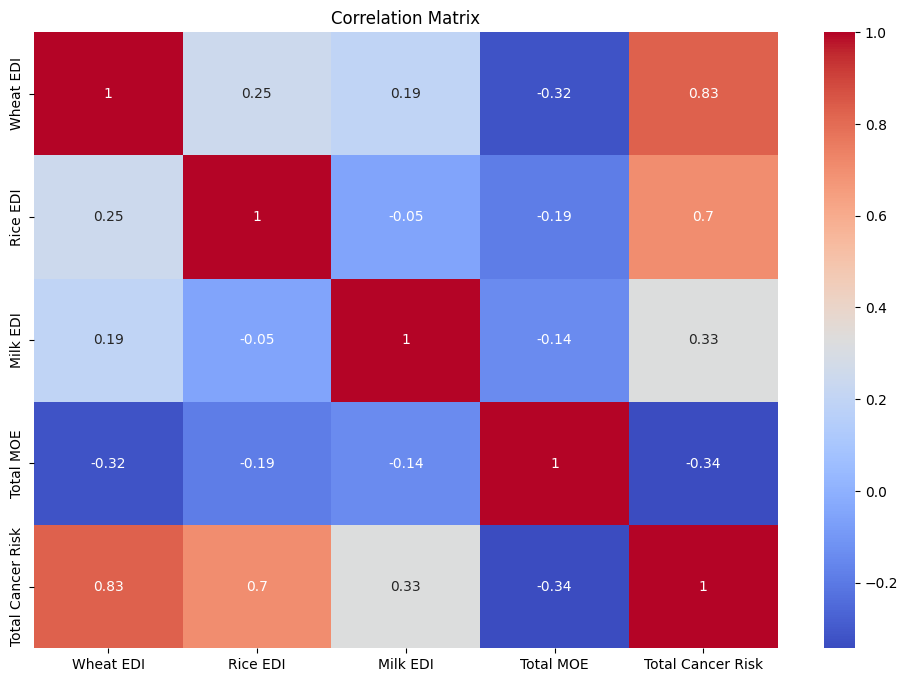

In [ ]:
corr_data = smm[['Wheat EDI','Rice EDI','Milk EDI','Total MOE','Total Cancer Risk']]
# Correlation matrix
correlation_matrix = corr_data.corr()

# Visualize correlations using heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
correlation_matrix

,Wheat EDI,Rice EDI,Milk EDI,Total MOE,Total Cancer Risk
Wheat EDI,1.000000,0.247524,0.193041,-0.319700,0.828962
Rice EDI,0.247524,1.000000,-0.050103,-0.187969,0.702307
Milk EDI,0.193041,-0.050103,1.000000,-0.139321,0.325471
Total MOE,-0.319700,-0.187969,-0.139321,1.000000,-0.342947
Total Cancer Risk,0.828962,0.702307,0.325471,-0.342947,1.000000


### Step 24 — Hypothesis test: two-sample t-test

- Splits the metric of interest into two groups (here, male vs female).
- Runs an independent two-sample t-test and prints the test statistic and p-value.

In [ ]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, zscore

male_risk = smm[smm['Gender'] == 'Male']['Total Cancer Risk']
female_risk = smm[smm['Gender'] == 'Female']['Total Cancer Risk']

t_stat, p_value = ttest_ind(male_risk, female_risk)
print("T-test Results:", t_stat, p_value)


T-test Results: 3.1694956236542495 0.0017857695407943362


In [ ]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, zscore

male_risk = smm[smm['Gender'] == 'Male']['Total MOE']
female_risk = smm[smm['Gender'] == 'Female']['Total MOE']

t_stat, p_value = ttest_ind(male_risk, female_risk)
print("T-test Results:", t_stat, p_value)


T-test Results: -2.6927967105780586 0.007732749968265077


### Step 25 — Hypothesis test: one-way ANOVA

- Collects the metric values for each category level and runs a one-way ANOVA.
- This tests whether group means differ beyond what we'd expect by chance.

In [ ]:
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
anova_results = f_oneway(*[smm[smm['BMI_Category'] == category]['Total Cancer Risk'] for category in labels])
print("ANOVA Results:", anova_results)


ANOVA Results: F_onewayResult(statistic=7.3177662056068655, pvalue=0.00011611568711117119)


In [ ]:
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
anova_results = f_oneway(*[smm[smm['BMI_Category'] == category]['Total MOE'] for category in labels])
print("ANOVA Results:", anova_results)


ANOVA Results: F_onewayResult(statistic=1.4648809214781957, pvalue=0.22561940512055878)


In [ ]:
labels = list(smm['Age'].unique())
anova_results = f_oneway(*[smm[smm['Age'] == category]['Total Cancer Risk'] for category in labels])
print("ANOVA Results:", anova_results)


ANOVA Results: F_onewayResult(statistic=0.7485412445875054, pvalue=0.6113179092171621)


In [ ]:
labels = list(smm['Age'].unique())
anova_results = f_oneway(*[smm[smm['Age'] == category]['Total MOE'] for category in labels])
print("ANOVA Results:", anova_results)

ANOVA Results: F_onewayResult(statistic=0.3496904093033787, pvalue=0.909403873986262)


In [ ]:
labels = list(smm['Location'].unique())
anova_results = f_oneway(*[smm[smm['Location'] == category]['Total Cancer Risk'] for category in labels])
print("ANOVA Results:", anova_results)


ANOVA Results: F_onewayResult(statistic=0.28652553397555164, pvalue=0.751200503126515)


In [ ]:
labels = list(smm['Location'].unique())
anova_results = f_oneway(*[smm[smm['Location'] == category]['Total MOE'] for category in labels])
print("ANOVA Results:", anova_results)

ANOVA Results: F_onewayResult(statistic=0.14412140022159375, pvalue=0.8658797462969474)


### Step 26 — Scatter plot + correlation annotation

- Calls the helper function to visualize the relationship between two variables.
- The annotation on the plot shows the Pearson correlation coefficient for quick interpretation.

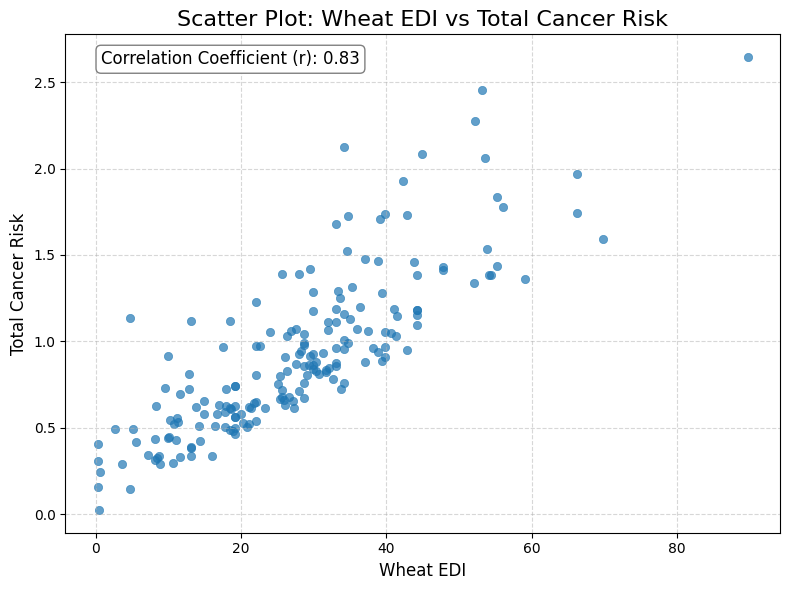

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to create a scatter plot with correlation coefficient
def scatter_plot_with_correlation(df, col_x, col_y):
    # Calculate the Pearson correlation coefficient
    corr_coeff = df[[col_x, col_y]].corr().iloc[0, 1]

    # Create scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=col_x, y=col_y, data=df, alpha=0.7, edgecolor=None)

    # Annotate correlation coefficient on the plot
    plt.text(
        x=0.05, y=0.95,
        s=f'Correlation Coefficient (r): {corr_coeff:.2f}',
        fontsize=12, ha='left', va='center', transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
    )

    # Add titles and labels
    plt.title(f'Scatter Plot: {col_x} vs {col_y}', fontsize=16)
    plt.xlabel(col_x, fontsize=12)
    plt.ylabel(col_y, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage:
# Replace 'column_x' and 'column_y' with your actual dataframe column names
scatter_plot_with_correlation(smm, 'Wheat EDI', 'Total Cancer Risk')


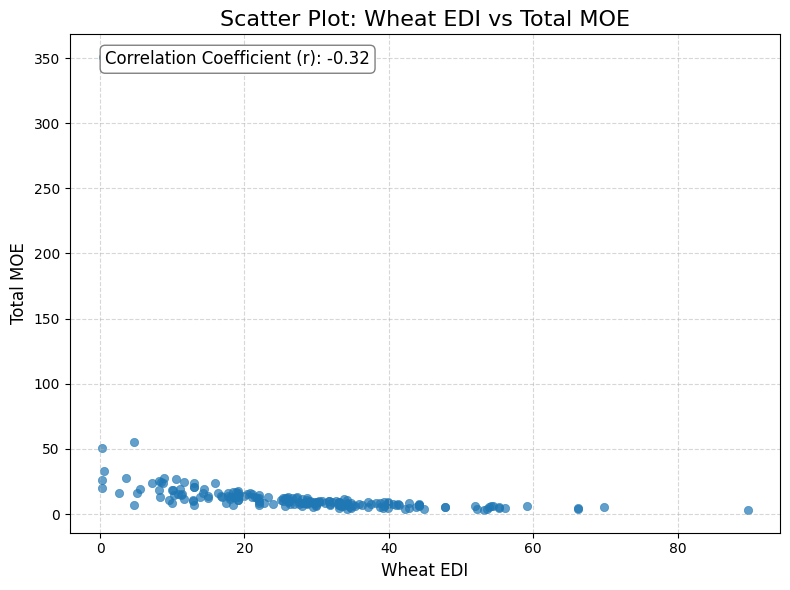

In [ ]:
scatter_plot_with_correlation(smm, 'Wheat EDI', 'Total MOE')

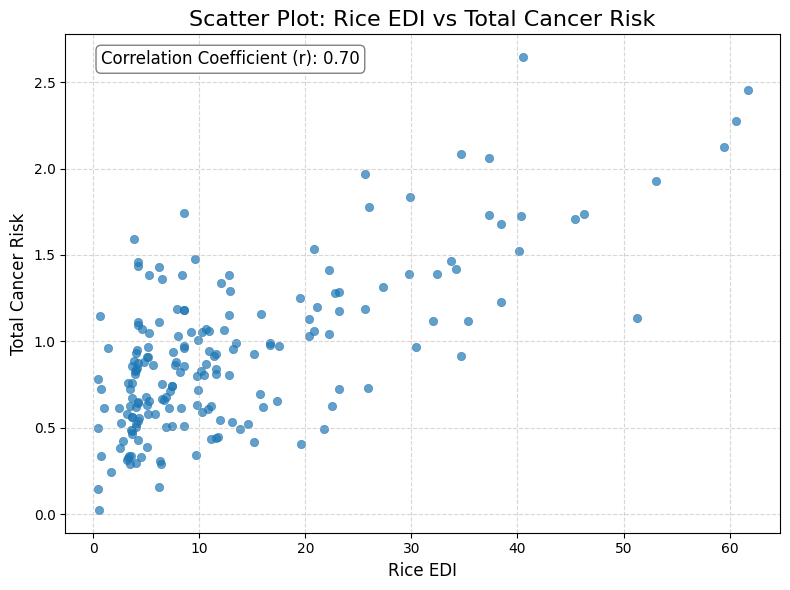

In [ ]:
scatter_plot_with_correlation(smm, 'Rice EDI', 'Total Cancer Risk')

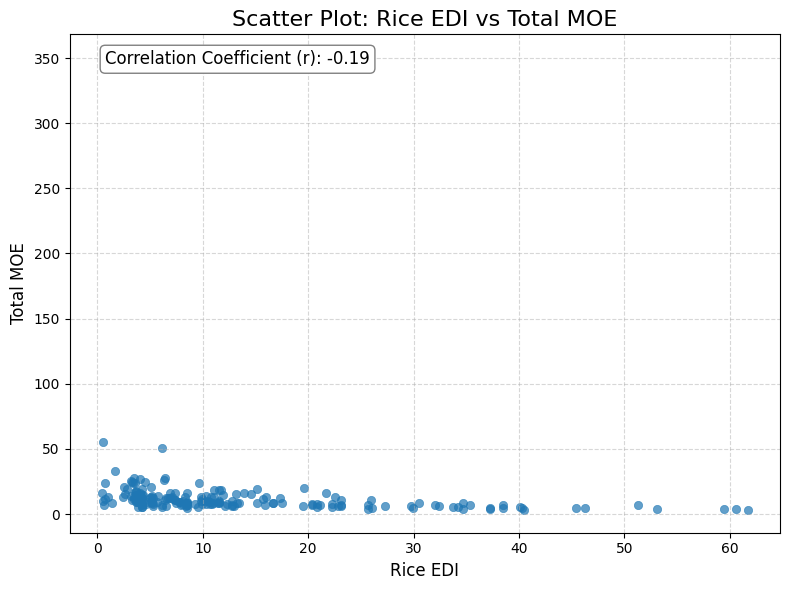

In [ ]:
scatter_plot_with_correlation(smm, 'Rice EDI', 'Total MOE')

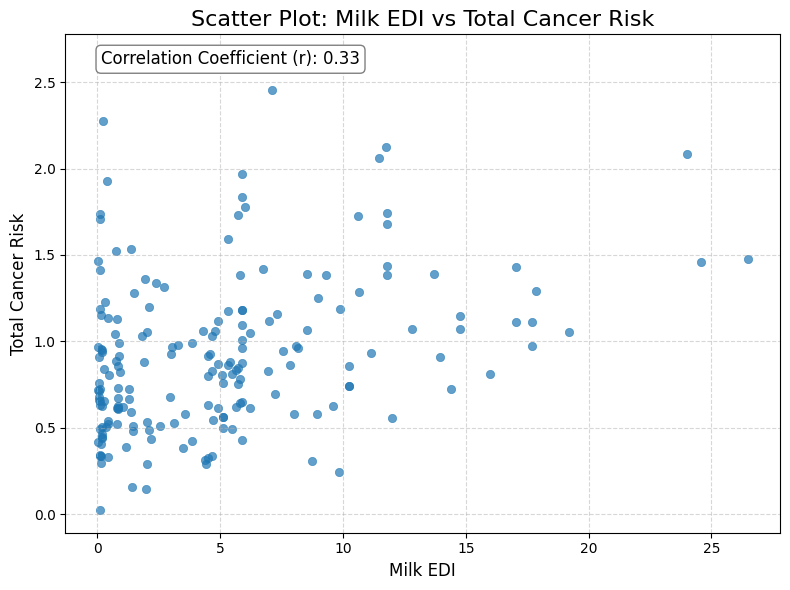

In [ ]:
scatter_plot_with_correlation(smm, 'Milk EDI', 'Total Cancer Risk')

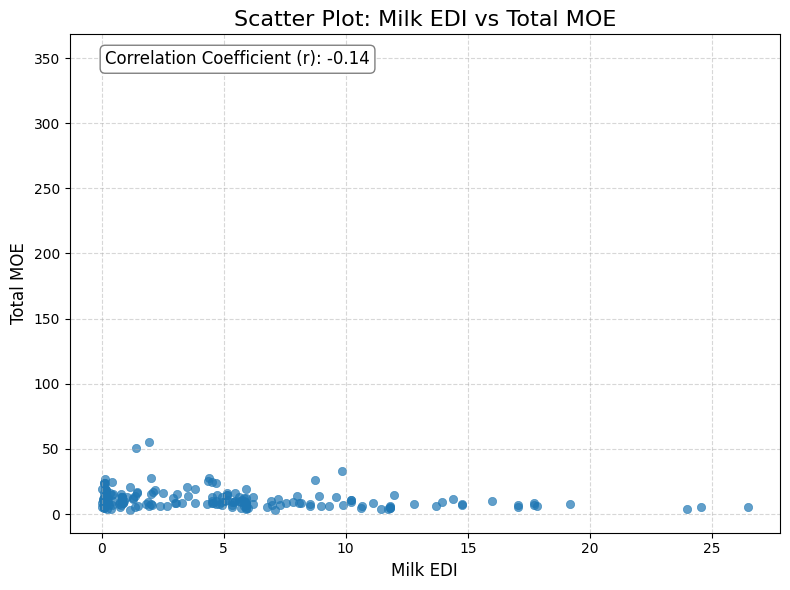

In [ ]:
scatter_plot_with_correlation(smm, 'Milk EDI', 'Total MOE')

### Step 27 — Bar chart: categorical distribution

- Counts category frequencies and plots them as a bar chart.
- Useful for summarizing respondent demographics (e.g., gender/age/location/BMI categories).

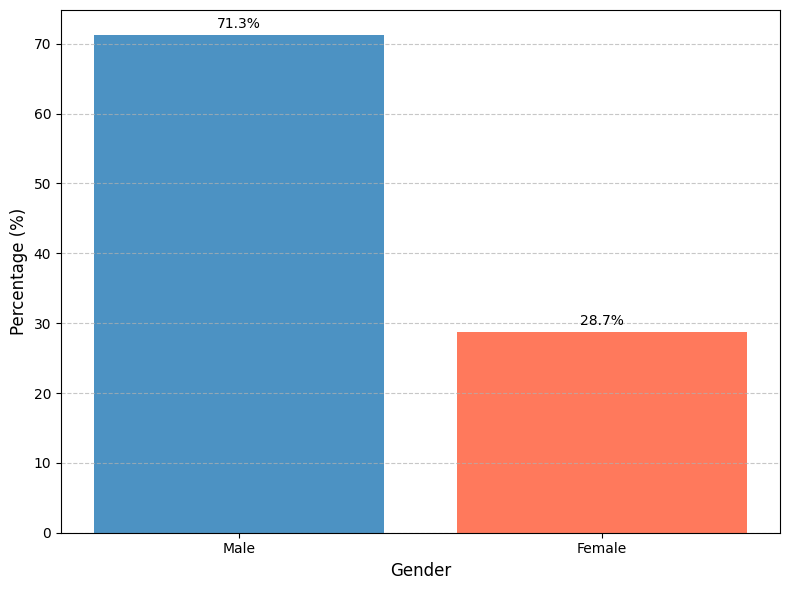

In [8]:
import matplotlib.pyplot as plt

# Example data: Replace this with the actual data
gender_counts = smm['Gender'].value_counts()  # Count occurrences of Male and Female

# Calculate percentages
total_count = gender_counts.sum()
gender_percentages = (gender_counts / total_count) * 100

# Define colors for bars
colors = ['#1f77b4', '#ff5733']  # Blue for Male, Red for Female

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(gender_percentages.index, gender_percentages.values, color=colors, alpha=0.8)

# Add labels and title
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
#plt.title('Gender Distribution', fontsize=16)

# Add percentage labels on top of the bars
for index, value in enumerate(gender_percentages.values):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tighten layout
plt.tight_layout()

# Display the chart
plt.show()



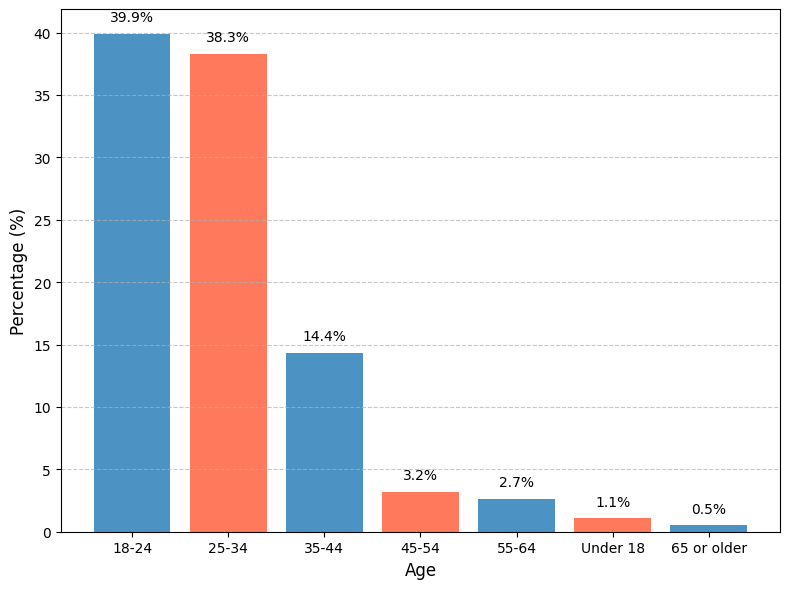

In [9]:
import matplotlib.pyplot as plt

# Example data: Replace this with the actual data
gender_counts = smm['Age'].value_counts()  # Count occurrences of Male and Female

# Calculate percentages
total_count = gender_counts.sum()
gender_percentages = (gender_counts / total_count) * 100

# Define colors for bars
colors = ['#1f77b4', '#ff5733']  # Blue for Male, Red for Female

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(gender_percentages.index, gender_percentages.values, color=colors, alpha=0.8)

# Add labels and title
plt.xlabel('Age', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
#plt.title('Gender Distribution', fontsize=16)

# Add percentage labels on top of the bars
for index, value in enumerate(gender_percentages.values):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tighten layout
plt.tight_layout()

# Display the chart
plt.show()


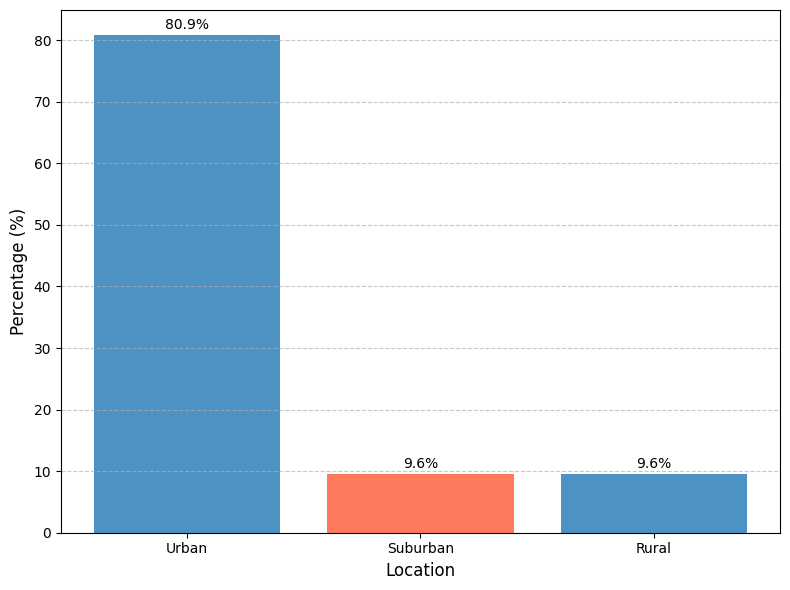

In [10]:
import matplotlib.pyplot as plt

# Example data: Replace this with the actual data
gender_counts = smm['Location'].value_counts()  # Count occurrences of Male and Female

# Calculate percentages
total_count = gender_counts.sum()
gender_percentages = (gender_counts / total_count) * 100

# Define colors for bars
colors = ['#1f77b4', '#ff5733']  # Blue for Male, Red for Female

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(gender_percentages.index, gender_percentages.values, color=colors, alpha=0.8)

# Add labels and title
plt.xlabel('Location', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
#plt.title('Gender Distribution', fontsize=16)

# Add percentage labels on top of the bars
for index, value in enumerate(gender_percentages.values):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tighten layout
plt.tight_layout()

# Display the chart
plt.show()

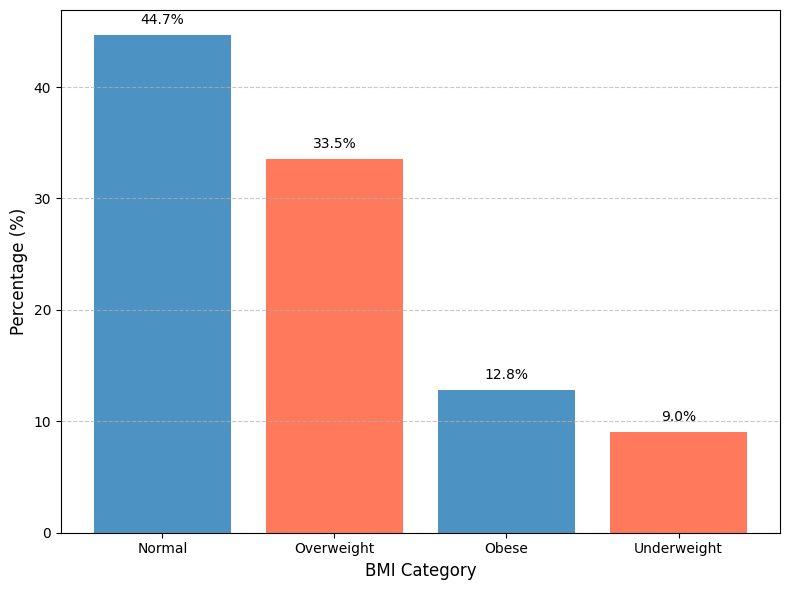

In [11]:
import matplotlib.pyplot as plt

# Example data: Replace this with the actual data
gender_counts = smm['BMI_Category'].value_counts()  # Count occurrences of Male and Female

# Calculate percentages
total_count = gender_counts.sum()
gender_percentages = (gender_counts / total_count) * 100

# Define colors for bars
colors = ['#1f77b4', '#ff5733']  # Blue for Male, Red for Female

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(gender_percentages.index, gender_percentages.values, color=colors, alpha=0.8)

# Add labels and title
plt.xlabel('BMI Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
#plt.title('Gender Distribution', fontsize=16)

# Add percentage labels on top of the bars
for index, value in enumerate(gender_percentages.values):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tighten layout
plt.tight_layout()

# Display the chart
plt.show()

### Step 28 — Histogram + KDE: distribution of a metric

- Plots the distribution of a selected numeric column using a histogram.
- Overlays a KDE curve to show a smoothed estimate of the underlying density.

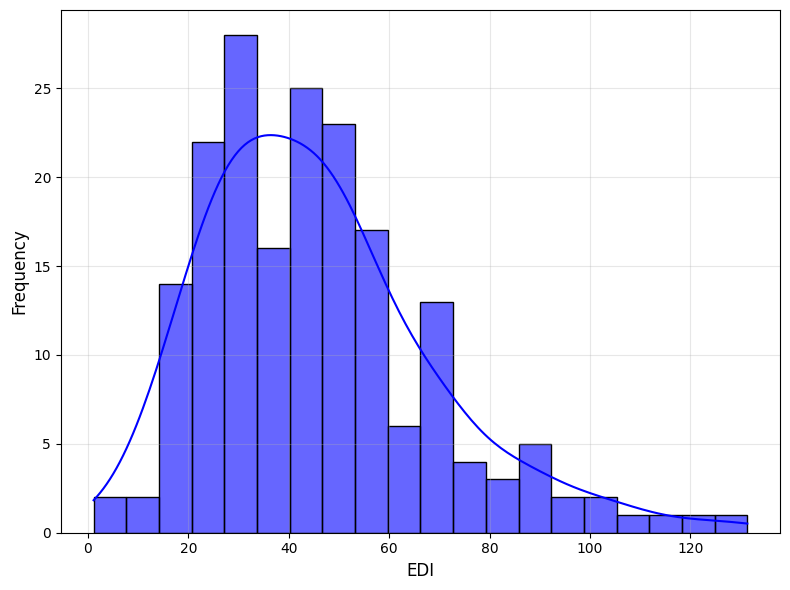

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example data: Replace this with your actual data
# Assuming `data` is a DataFrame, and we are plotting the 'BMI' column
column_to_plot = 'Total EDI'

# Create a histogram
plt.figure(figsize=(8, 6))
sns.histplot(smm[column_to_plot], bins=20, kde=True, color='blue', alpha=0.6)

# Add title and labels
#plt.title(f'Histogram of {column_to_plot}', fontsize=16)
plt.xlabel('EDI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()


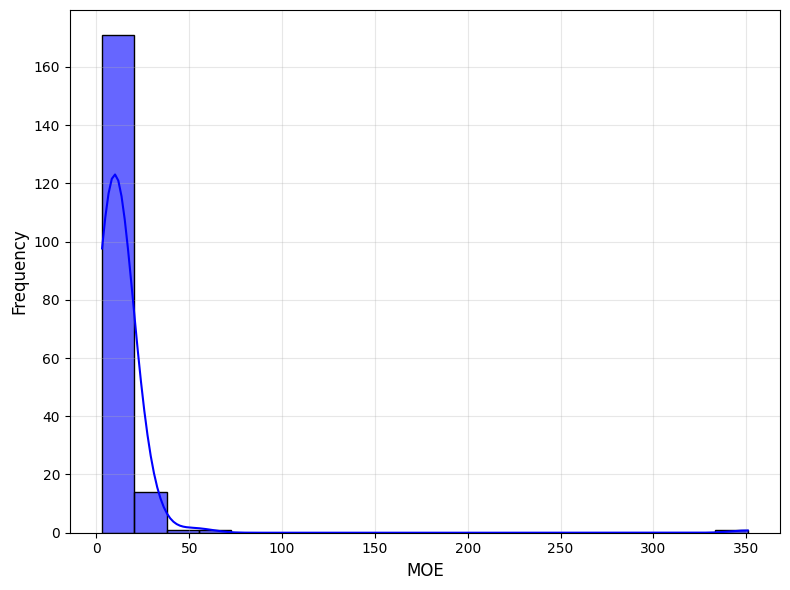

In [ ]:
# Example data: Replace this with your actual data
# Assuming `data` is a DataFrame, and we are plotting the 'BMI' column
column_to_plot = 'Total MOE'

# Create a histogram
plt.figure(figsize=(8, 6))
sns.histplot(smm[column_to_plot], bins=20, kde=True, color='blue', alpha=0.6)

# Add title and labels
#plt.title(f'Histogram of {column_to_plot}', fontsize=16)
plt.xlabel('MOE', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

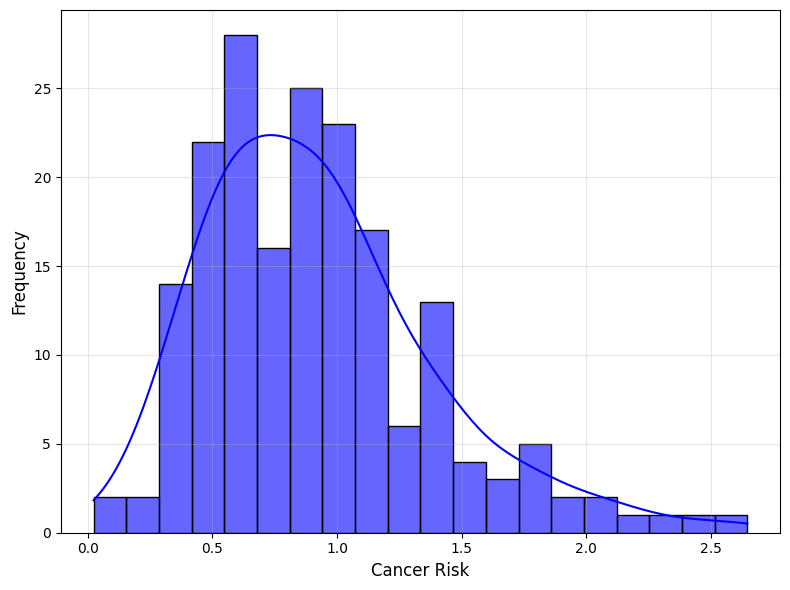

In [ ]:
# Example data: Replace this with your actual data
# Assuming `data` is a DataFrame, and we are plotting the 'BMI' column
column_to_plot = 'Total Cancer Risk'

# Create a histogram
plt.figure(figsize=(8, 6))
sns.histplot(smm[column_to_plot], bins=20, kde=True, color='blue', alpha=0.6)

# Add title and labels
#plt.title(f'Histogram of {column_to_plot}', fontsize=16)
plt.xlabel('Cancer Risk', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

### Step 29 — 95% confidence interval for Total EDI

- Treats `Total EDI` as a sample and computes the sample mean and standard error.
- Uses the t-distribution (with n-1 degrees of freedom) to compute the margin of error and confidence interval.

In [ ]:
import numpy as np
from scipy.stats import t
# Given data
data = np.array(smm['Total EDI'])
confidence_level = 0.95 # 95% confidence level
# Step 1: Calculate the sample mean and standard deviation
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1) # ddof=1 for sample standard deviation
# Step 2: Calculate the standard error of the mean
standard_error = sample_std / np.sqrt(len(data))
# Step 3: Find the critical value (t-score) for the confidence level
df = len(data) - 1 # degrees of freedom
t_score = t.ppf((1 + confidence_level) / 2, df)
# Step 4: Calculate the margin of error
margin_of_error = t_score * standard_error
# Step 5: Calculate the confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error
# Display the results
print(f"Sample Mean: {sample_mean:.4f}")
print(f"Standard Error: {standard_error:.4f}")
print(f"Critical Value (t-score): {t_score:.4f}")
print(f"Margin of Error: {margin_of_error:.4f}")
print(f"95% Confidence Interval: ({lower_bound:.4f},{upper_bound:.4f})")

Sample Mean: 45.7361
Standard Error: 1.6692
Critical Value (t-score): 1.9727
Margin of Error: 3.2929
95% Confidence Interval: (42.4432,49.0289)


### Step 30 — 95% confidence interval for Total MOE

- Treats `Total MOE` as a sample and computes the sample mean and standard error.
- Uses the t-distribution (with n-1 degrees of freedom) to compute the margin of error and confidence interval.

In [ ]:
# Given data
data = np.array(smm['Total MOE'])
confidence_level = 0.95 # 95% confidence level
# Step 1: Calculate the sample mean and standard deviation
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1) # ddof=1 for sample standard deviation
# Step 2: Calculate the standard error of the mean
standard_error = sample_std / np.sqrt(len(data))
# Step 3: Find the critical value (t-score) for the confidence level
df = len(data) - 1 # degrees of freedom
t_score = t.ppf((1 + confidence_level) / 2, df)
# Step 4: Calculate the margin of error
margin_of_error = t_score * standard_error
# Step 5: Calculate the confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error
# Display the results
print(f"Sample Mean: {sample_mean:.4f}")
print(f"Standard Error: {standard_error:.4f}")
print(f"Critical Value (t-score): {t_score:.4f}")
print(f"Margin of Error: {margin_of_error:.4f}")
print(f"95% Confidence Interval: ({lower_bound:.4f},{upper_bound:.4f})")

Sample Mean: 13.1429
Standard Error: 1.8786
Critical Value (t-score): 1.9727
Margin of Error: 3.7061
95% Confidence Interval: (9.4368,16.8490)


### Step 31 — 95% confidence interval for Total Cancer Risk

- Treats `Total Cancer Risk` as a sample and computes the sample mean and standard error.
- Uses the t-distribution (with n-1 degrees of freedom) to compute the margin of error and confidence interval.

In [ ]:
# Given data
data = np.array(smm['Total Cancer Risk'])
confidence_level = 0.95 # 95% confidence level
# Step 1: Calculate the sample mean and standard deviation
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1) # ddof=1 for sample standard deviation
# Step 2: Calculate the standard error of the mean
standard_error = sample_std / np.sqrt(len(data))
# Step 3: Find the critical value (t-score) for the confidence level
df = len(data) - 1 # degrees of freedom
t_score = t.ppf((1 + confidence_level) / 2, df)
# Step 4: Calculate the margin of error
margin_of_error = t_score * standard_error
# Step 5: Calculate the confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error
# Display the results
print(f"Sample Mean: {sample_mean:.4f}")
print(f"Standard Error: {standard_error:.4f}")
print(f"Critical Value (t-score): {t_score:.4f}")
print(f"Margin of Error: {margin_of_error:.4f}")
print(f"95% Confidence Interval: ({lower_bound:.4f},{upper_bound:.4f})")

Sample Mean: 0.9216
Standard Error: 0.0336
Critical Value (t-score): 1.9727
Margin of Error: 0.0664
95% Confidence Interval: (0.8552,0.9879)
